In [25]:
import random

from matplotlib import pyplot as plt
import pandas as pd
df = pd.read_csv("data/v1_world-happiness-report-2017.csv",low_memory=False);
gdp=df["Economy..GDP.per.Capita."].tolist()
freedom=df["Freedom"].tolist()
happy=df["Happiness.Score"].tolist()

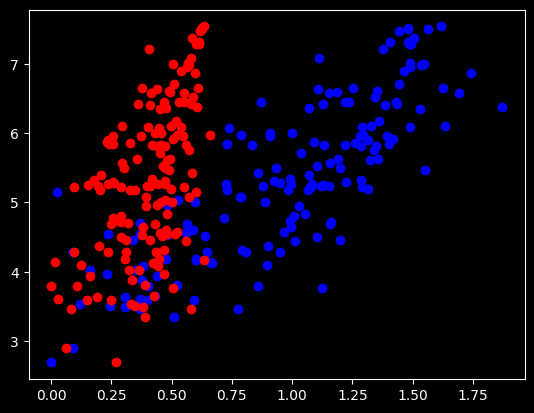

In [26]:
from matplotlib import pyplot as plt
plt.plot(gdp,happy,"bo")
plt.plot(freedom,happy,"ro")
plt.show()

In [94]:
import numpy as np
import torch

np.random.seed(47)
import numpy as np

np.random.seed(47)
indexes = [i for i in range(len(happy))]
trainSample = np.random.choice(indexes, int(0.8 * len(happy)), replace=False)
validationSample = [i for i in indexes if not i in trainSample]

trainInputsGdp = [gdp[i] for i in trainSample]
trainInputsFreedom = [freedom[i] for i in trainSample]

trainOutputs = [happy[i] for i in trainSample]

validationInputsGdp = [gdp[i] for i in validationSample]
validationInputsFreedom = [freedom[i] for i in validationSample]
validationOutputs = [happy[i] for i in validationSample]



In [95]:
def normalize(data):
    mn, mx = min(data), max(data)
    return [(x - mn) / (mx - mn) for x in data]

trainInputsGdp = normalize(trainInputsGdp)
trainInputsFreedom = normalize(trainInputsFreedom)




In [103]:
import random
class Linear2param:
    def __init__(self):
        self.a=random.uniform(0,1)
        self.b=random.uniform(0,1)
        self.c=random.uniform(0,1)
        self.training_nr=0
    def __call__(self,x,y):
        return self.a*x+self.b*y+self.c
    def predict(self,x,y):
        return self(x,y)
    def backward(self,x,y,rez):
        error=self.a*x+self.b*y+self.c-rez
        grad_a=2 * error * x
        grad_b=2 * error * y
        grad_c=2 * error
        if self.training_nr>10000 :
            self.a += -grad_a*0.01
            self.b += -grad_b*0.01
            self.c += -grad_c*0.01
        if self.training_nr>20000 :
            self.a += -grad_a*0.001
            self.b += -grad_b*0.001
            self.c += -grad_c*0.001
        self.b += -grad_b*0.1
        self.b += -grad_b*0.1
        self.c += -grad_c*0.1
        self.training_nr+=1

l=Linear2param()





In [106]:
for i in range(30000):
    loss=0
    for x,y,z in zip(trainInputsGdp,trainInputsFreedom,trainOutputs):
        loss+=(l(x,y)-z)**2
        l.backward(x,y,z)
    avg_loss=loss/len(trainInputsGdp)
    print(avg_loss)


0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513
0.41869022747748513


In [105]:
#testing on validation data
for i in range(len(validationInputsGdp)):
    loss = (l(validationInputsGdp[i], validationInputsFreedom[i]) - validationOutputs[i]) ** 2
    print(
        f"input: ({validationInputsGdp[i]}, {validationInputsFreedom[i]}), true output: {validationOutputs[i]}, predicted output: {l(validationInputsGdp[i], validationInputsFreedom[i])}, loss: {loss}")


input: (1.443571925, 0.617950857), true output: 7.468999863, predicted output: 8.179252495466962, loss: 0.5044588019262495
input: (1.405706048, 0.61406213), true output: 7.31400013, predicted output: 8.057481677854808, loss: 0.5527648120005808
input: (1.494387269, 0.612924099), true output: 7.28399992, predicted output: 8.325752278974885, loss: 1.085247977429738
input: (1.25278461, 0.376895279), true output: 6.65199995, predicted output: 7.200088131544936, loss: 0.3004006547492341
input: (1.10735321, 0.437453747), true output: 6.635000229, predicted output: 6.857039408240524, loss: 0.04930139711780568
input: (1.185295463, 0.494519204), true output: 6.598999977, predicted output: 7.188686632558317, loss: 0.3477303517435536
input: (1.217559695, 0.579392254), true output: 6.453999996, predicted output: 7.427093781172335, loss: 0.9469115147410219
input: (1.384397864, 0.40878123), true output: 6.402999878, predicted output: 7.653663256028045, loss: 1.56415888514052
input: (1.870765686, 0.60